Celem projektu było zbudowanie modelu klasyfikacyjnego przewidującego wystąpienie choroby serca na podstawie danych medycznych pacjentów.

W projekcie:

* wykonałam analizę danych
* przygotowałam dane
* zbudowałam modele klasyfikacyjne
* przeprowadziłam regularyzację
* wykonałam ranking istotności cech
* porównałam wyniki modeli



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Wstępna analiza

## Wczytanie danych

Dane składają się z kolumn:
* Age - wiek pacjenta
* Sex - płeć (M/F)
* ChestPainType - typ bólu w klatce piersiowej
* RestingBP - ciśnienie spoczynkowe
* Cholesterol - poziom cholesterolu
* FastingBS - poziom cukru na czczo
* RestingECG - wynik EKG
* MaxHR - maksymalne tętno
* ExerciseAngina - dusznica wysiłkowa (czy podczas wysiłku fizycznego pojawia się ból w klatce piersiowej)
* Oldpeak - depresja odcinka ST (jak bardzo spada sygnał serca podczas wysiłku)
* ST_Slope - nachylenie ST (jak wygląda linia ST na EKG podczas wysiłku)
* HeartDisease - zmienna klasyfikacyjna (0/1)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/WdUM/projekt 1/heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [ ]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

## Informacje o zbiorze

Zbiór danych zawiera 918 rekordów oraz 11 cech opisujących stan zdrowia pacjentów w kontekście chorób serca oraz zmienną docelową HeartDisease.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


## Podstawowe statystyki

W kolumnach:
* RestingBP
* Cholesterol

pojawiają się wartości 0, które w danych medycznych są nienaturalne. Mogą one oznaczać brak danych, więc je usuwamy.

In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
((df['RestingBP'] == 0) | (df['Cholesterol'] == 0)).sum()

np.int64(172)

In [ ]:
(df['HeartDisease'] == 1).sum()

np.int64(508)

In [ ]:
print(round(152/356*100, 2), "%")

42.7 %


In [ ]:
df.drop(df[(df['RestingBP'] == 0) | (df['Cholesterol'] == 0)].index, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 746 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             746 non-null    int64  
 1   Sex             746 non-null    object 
 2   ChestPainType   746 non-null    object 
 3   RestingBP       746 non-null    int64  
 4   Cholesterol     746 non-null    int64  
 5   FastingBS       746 non-null    int64  
 6   RestingECG      746 non-null    object 
 7   MaxHR           746 non-null    int64  
 8   ExerciseAngina  746 non-null    object 
 9   Oldpeak         746 non-null    float64
 10  ST_Slope        746 non-null    object 
 11  HeartDisease    746 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 75.8+ KB


In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000
mean,52.882038,133.022788,244.635389,0.167560,140.226542,0.901609,0.477212
std,9.505888,17.282750,59.153524,0.373726,24.524107,1.072861,0.499816
min,28.000000,92.000000,85.000000,0.000000,69.000000,-0.100000,0.000000
25%,46.000000,120.000000,207.250000,0.000000,122.000000,0.000000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,140.000000,0.500000,0.000000
75%,59.000000,140.000000,275.000000,0.000000,160.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Sprawdzenie brakujących danych

W zbiorze danych nie występują brakujące wartości.

In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


# Skalowanie danych do przedziału [0,1]

W celu ujednolicenia zakresu wartości cech zastosowano skalowanie danych metodą Min-Max, która przekształca wartości zmiennych numerycznych do przedziału [0, 1]. Dzięki temu wszystkie cechy mają porównywalną skalę, co jest szczególnie istotne dla algorytmów uczenia maszynowego wykorzystujących odległości między obserwacjami.

Dodatkowo zmienne kategoryczne zostały zakodowane do postaci numerycznej przy użyciu metody Label Encoding z biblioteki scikit-learn. W rezultacie otrzymano w pełni numeryczny zbiór danych przygotowany do dalszej analizy i budowy modeli klasyfikacyjnych.

In [ ]:
num_cols = df.select_dtypes(include = 'number').columns.to_list()
num_cols.remove('HeartDisease')

In [ ]:
cat_cols = df.select_dtypes(include = 'object').columns.to_list()

In [ ]:
target = df['HeartDisease']

In [ ]:
df_encoded = df.copy()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [ ]:
df_encoded.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000
mean,0.507797,0.756032,0.840483,0.379841,0.308176,0.167560,0.931635,0.535538,0.384718,0.158985,1.410188,0.477212
std,0.193998,0.429762,0.958198,0.160025,0.114196,0.373726,0.631939,0.184392,0.486855,0.170295,0.598076,0.499816
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.367347,1.000000,0.000000,0.259259,0.236004,0.000000,1.000000,0.398496,0.000000,0.015873,1.000000,0.000000
50%,0.530612,1.000000,1.000000,0.351852,0.293436,0.000000,1.000000,0.533835,0.000000,0.095238,1.000000,0.000000
75%,0.632653,1.000000,2.000000,0.444444,0.366795,0.000000,1.000000,0.684211,1.000000,0.253968,2.000000,1.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000


# Analiza graficzna

## Histogramy (rozkład zmiennych numerycznych)

Age (Wiek): Rozkład zbliżony do normalnego. Najliczniejszą grupę stanowią osoby w wieku 50–60 lat. Badanie obejmuje głównie osoby dojrzałe i starsze.

RestingBP (Ciśnienie spoczynkowe): Większość wyników oscyluje w granicach 120–140 mmHg. Widać niewielką liczbę wartości odstających powyżej 180, co może sugerować ciężkie nadciśnienie u niektórych pacjentów.

Cholesterol: Dominują wartości w przedziale 200–300 mg/dl.

MaxHR (Tętno maksymalne): Rozkład lewostronnie skośny. Większość pacjentów osiąga tętno maksymalne w przedziale 120–160 bpm.

FastingBS (Cukier na czczo): Zmienna binarna. Zdecydowana większość pacjentów (wartość 0) ma poziom cukru w normie. Mniejsza grupa (wartość 1) to osoby z podwyższonym cukrem, co jest istotnym czynnikiem ryzyka sercowo-naczyniowego.

Oldpeak (Obniżenie odcinka ST): Rozkład mocno prawostronnie skośny. Dla większości pacjentów wskaźnik ten wynosi 0 lub blisko 0. Wartości powyżej 2 są rzadsze i stanowią wyraźny sygnał potencjalnych zmian niedokrwiennych w sercu podczas wysiłku.

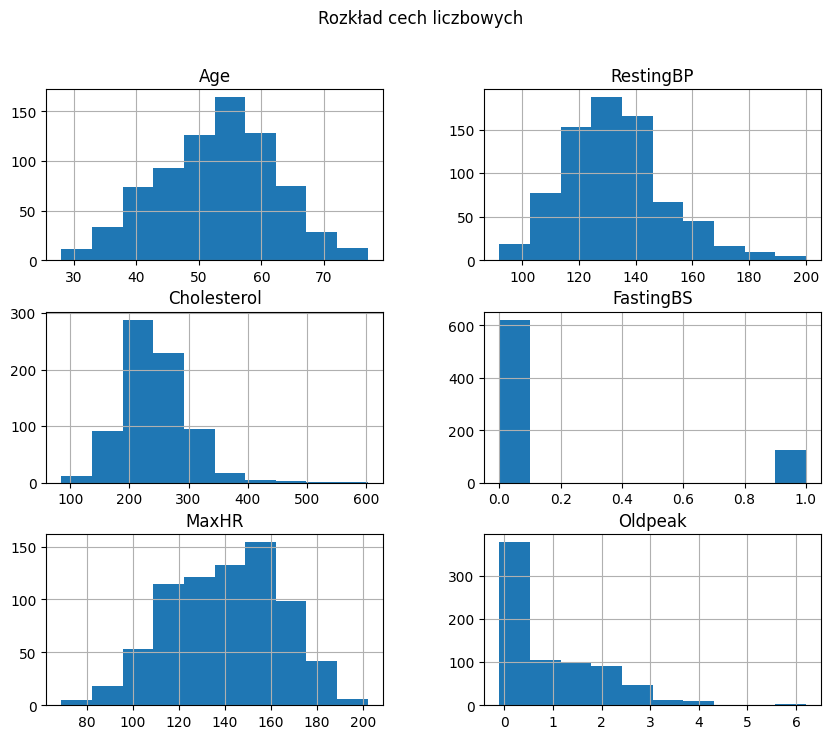

In [ ]:
df[num_cols].hist(figsize=(10,8))
plt.suptitle("Rozkład cech liczbowych")
plt.show()

## Rozkład zmiennej docelowej

Zmienna docelowa HeartDisease charakteryzuje się równomiernym rozkładem klas. Brak znaczącej dysproporcji pozwala na rzetelne trenowanie modelu klasyfikacyjnego bez ryzyka błędu wynikającego z dominacji jednej z grup.

In [ ]:
df.HeartDisease.value_counts(normalize=True)

,proportion
HeartDisease,
0,0.522788
1,0.477212


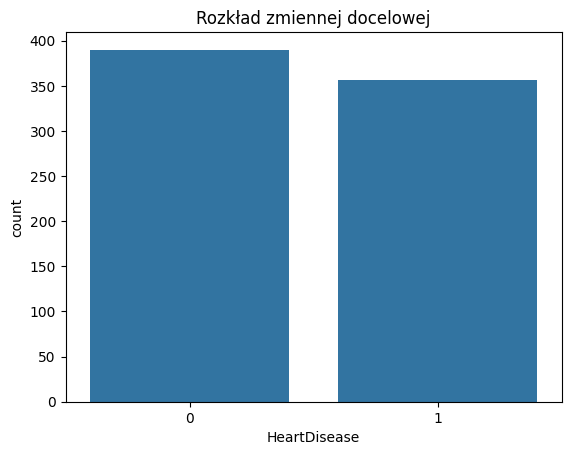

In [ ]:
sns.countplot(x="HeartDisease", data=df)
plt.title("Rozkład zmiennej docelowej")
plt.show()

**Zbiór danych jest względnie zbalansowany, dlatego nie zastosowano metody SMOTE.**

## Rozkład zmiennych kategorycznych a zmienna docelowa

Płeć (Sex): Analiza wskazuje, że mężczyźni są grupą znacznie bardziej obciążoną ryzykiem wystąpienia choroby serca. U kobiet liczba osób zdrowych wyraźnie dominuje nad chorymi, co potwierdza, że płeć będzie jednym z kluczowych predyktorów dla modelu.

Typ bólu (Chest Pain Type): Ból asymptomatyczny (ASY) jest bezdyskusyjnie najsilniejszym wskaźnikiem choroby. Warto zauważyć, że w pozostałych grupach (ATA, NAP) przewaga osób zdrowych jest miażdżąca. To kluczowa informacja – brak typowych objawów bólowych Paradoxalnie wiąże się w tym zbiorze z najwyższym ryzykiem klinicznym.

EKG spoczynkowe (RestingECG): Odstępstwa od normy (ST, LVH) wiążą się z większą proporcją osób chorych niż zdrowych. Jednak wykres potwierdza, że wynik „Normal” nie jest gwarantem zdrowia – duża grupa pacjentów z prawidłowym EKG spoczynkowym ma zdiagnozowaną chorobę, co sugeruje konieczność wykonania badań wysiłkowych.

Dusznicowa wysiłkowa (ExerciseAngina): Zmienna ta posiada ogromną moc różnicującą. Wystąpienie bólu podczas wysiłku (Y) niemal trzykrotnie zwiększa prawdopodobieństwo diagnozy pozytywnej. Brak bólu (N) jest z kolei silnie skorelowany ze zdrowym sercem.

Nachylenie odcinka ST (ST_Slope): To prawdopodobnie najsilniejszy predyktor. Wykres pokazuje ogromną dysproporcję: nachylenie Flat to zdecydowana większość przypadków chorobowych, podczas gdy Up niemal jednoznacznie wskazuje na brak schorzenia. Profil Down, choć mniej liczny, również wiąże się głównie z grupą chorych.

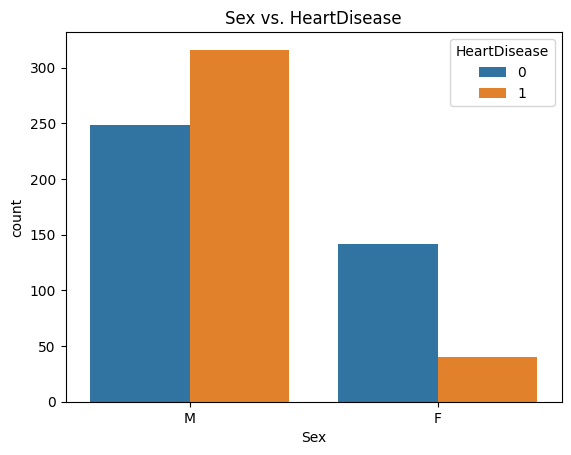

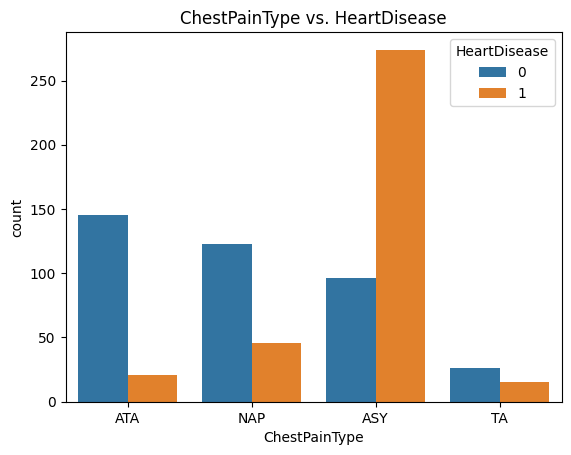

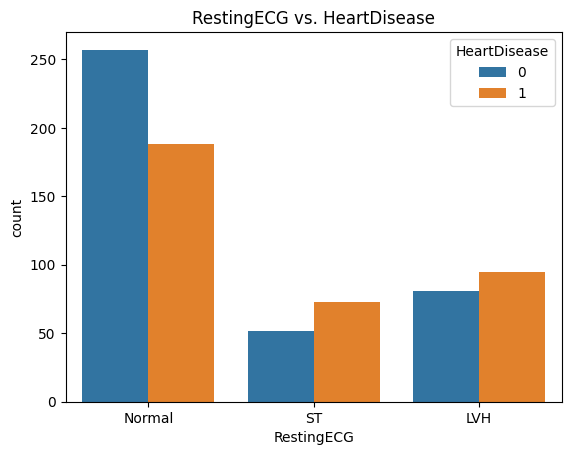

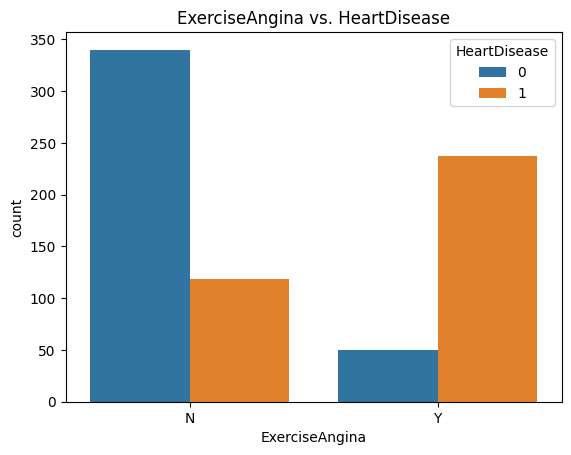

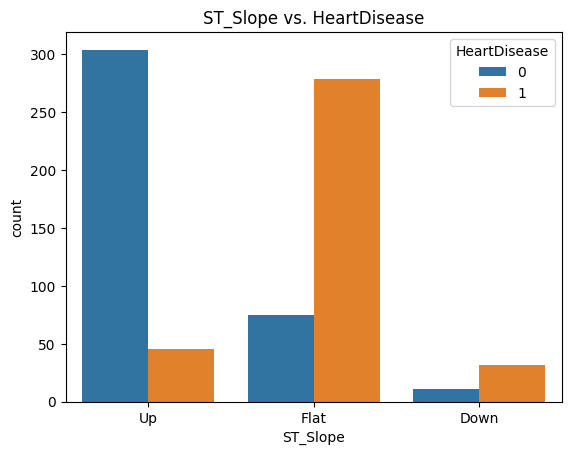

In [ ]:
for col in cat_cols:
  sns.countplot(x=col, hue="HeartDisease", data=df)
  plt.title(f"{col} vs. HeartDisease")
  plt.show()

# Macierz korelacji

Macierz korelacji potwierdziła, że zmienne związane z próbą wysiłkową (ST_Slope, ExerciseAngina, Oldpeak oraz MaxHR) wykazują najsilniejszy związek z występowaniem choroby serca. Współczynniki korelacji rzędu 0.38 – 0.60 dla tych cech wskazują na ich kluczowe znaczenie w procesie budowy modelu klasyfikacyjnego, podczas gdy parametry spoczynkowe (np. RestingECG) mają znacznie mniejszy wpływ na wynik końcowy.

In [ ]:
corr = df_encoded.corr()

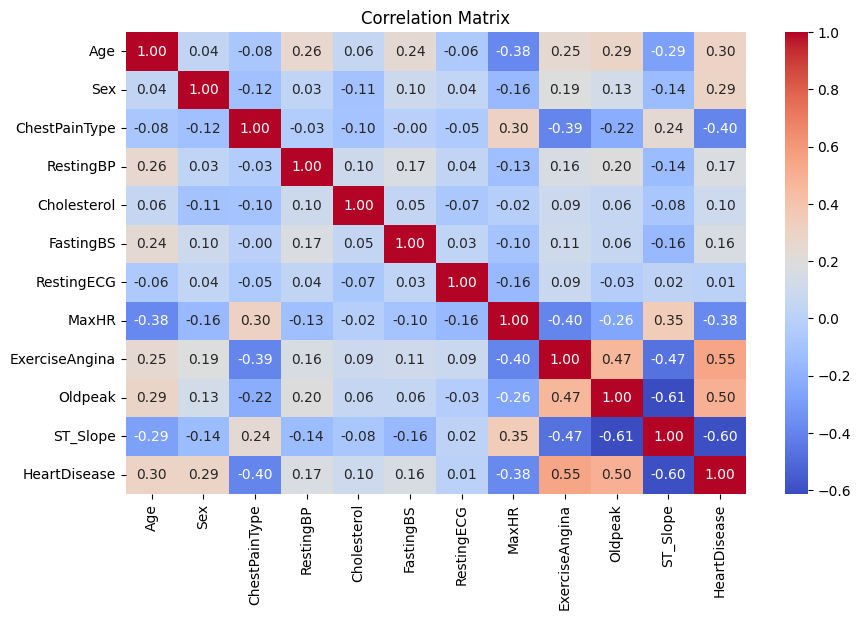

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Korelacja z klasą

In [ ]:
abs(corr["HeartDisease"]).sort_values(ascending=False)

,HeartDisease
HeartDisease,1.000000
ST_Slope,0.597334
ExerciseAngina,0.551834
Oldpeak,0.495696
ChestPainType,0.395776
MaxHR,0.377212
Age,0.298617
Sex,0.292779
RestingBP,0.173242
FastingBS,0.160594


# PCA

## Przygotowanie danych

In [ ]:
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

In [ ]:
from sklearn.decomposition import PCA

## PCA 2-wymiarowe

Wizualizacja pokazuje, że klasy osób zdrowych i chorych w znacznym stopniu się przenikają. Sugeruje to złożony i nieliniowy charakter powiązań między cechami a zmienną docelową. Taki rozkład oznacza, że model klasyfikacyjny musi wykorzystać zaawansowane relacje do skutecznej separacji grup.

In [ ]:
pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X)

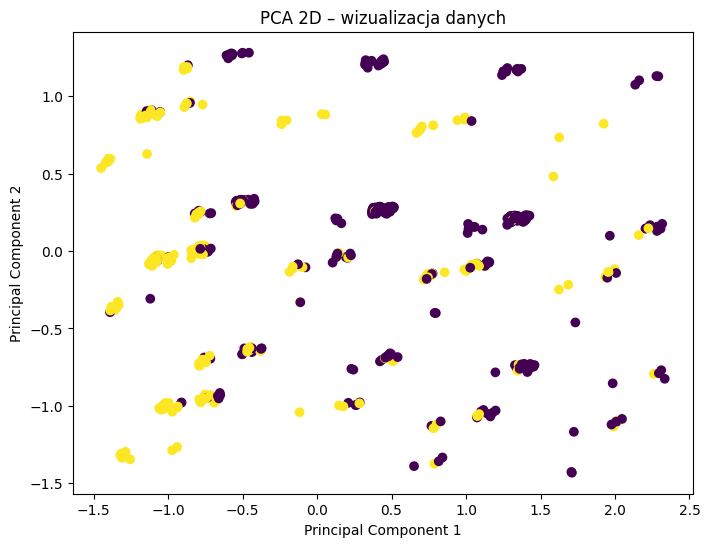

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca2[:,0],
    X_pca2[:,1],
    c=y,
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA 2D – wizualizacja danych")

plt.show()

In [ ]:
pca_2.explained_variance_ratio_

array([0.43166458, 0.16920226])

Pierwsza składowa (PC1) wyjaśnia 43,17% wariancji, a druga (PC2) 16,92%. Łącznie oba komponenty zachowują ponad 60% informacji zawartych w pierwotnym zbiorze danych. Pozwala to na skuteczną redukcję wymiarowości przy zachowaniu większości kluczowych sygnałów medycznych.

## PCA 3-wymiarowe

Dodanie trzeciego wymiaru ujawnia wyraźniejszą strukturę klastrową danych, wynikającą z obecności cech dyskretnych. Mimo lepszego odseparowania grup, w przestrzeni trójwymiarowej nadal widoczny jest obszar wspólny dla obu klas.

In [ ]:
pca_3 = PCA(n_components=3)
X_pca3 = pca_3.fit_transform(X)

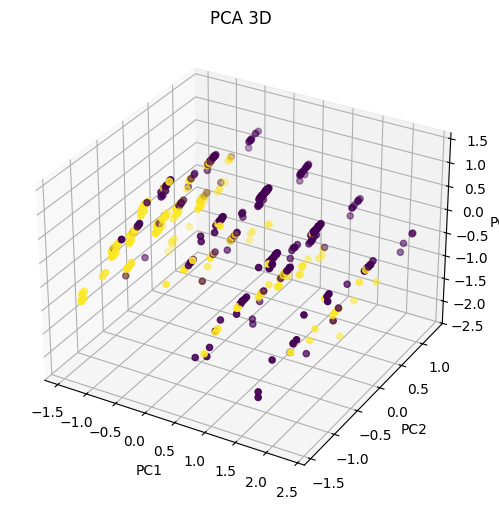

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca3[:,0],
    X_pca3[:,1],
    X_pca3[:,2],
    c=y
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("PCA 3D")

plt.show()

In [ ]:
pca_3.explained_variance_ratio_

array([0.43166458, 0.16920226, 0.16566371])

Trzy pierwsze składowe wyjaśniają łącznie 76,65% wariancji danych (PC1: 43,17%, PC2: 16,92%, PC3: 16,56%). Jest to wzrost o ponad 17 punktów procentowych względem modelu 2D. Tak wysoki wynik oznacza, że rzut trójwymiarowy zachowuje zdecydowaną większość istotnych informacji diagnostycznych zawartych w oryginalnym zbiorze.

# t-SNE

Algorytm t-SNE wyraźnie wyodrębnił lokalne grupy podobieństwa, jednak klasy osób zdrowych i chorych nadal częściowo na siebie nachodzą. To nakładanie się punktów (overlapping) wskazuje na istnienie przypadków o niejednoznacznych parametrach klinicznych, co bezpośrednio wpływa na ostateczną precyzję modeli. Taki rozkład potwierdza, że problem klasyfikacji chorób serca jest złożony, a dane medyczne rzadko pozwalają na idealne rozdzielenie grup w sposób liniowy.

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X)

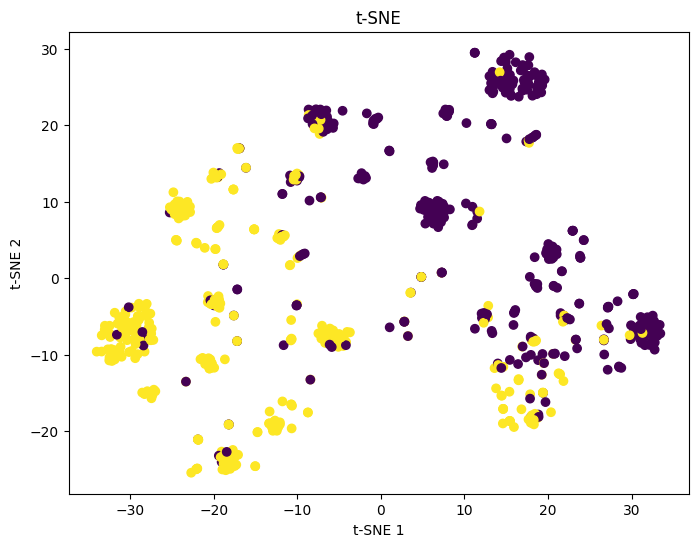

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.title("t-SNE")

plt.show()

# Regresja logistyczna

## Podział danych na zbiór treningowy i testowy

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Trenowanie regresji logistycznej

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

LogisticRegression()

## Dokładność modelu

In [ ]:
y_pred_log = log_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

acc_log = accuracy_score(y_test, y_pred_log)

print("Accuracy:", acc_log)

Accuracy: 0.8666666666666667


## Macierz pomyłek

Macierz pomyłek dla regresji logistycznej wykazuje wysoką skuteczność, osiągając ogólną dokładność na poziomie 87%. Model poprawnie zidentyfikował 67 przypadków chorych oraz 63 osoby zdrowe. Wyzwaniem pozostaje 12 przypadków False Negative (pacjenci chorzy sklasyfikowani jako zdrowi) oraz 8 przypadków False Positive. Błędy te wynikają z zaobserwowanego wcześniej w analizie t-SNE nakładania się cech klinicznych w obu grupach, co ogranicza możliwości pełnej separacji klas przez model liniowy.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_log = confusion_matrix(y_test, y_pred_log)

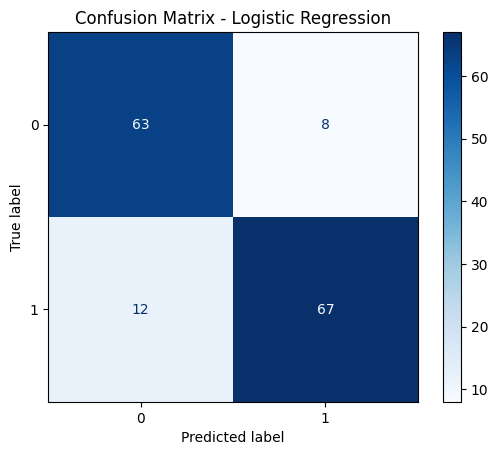

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Model wykazuje wysoką skuteczność w rozpoznawaniu osób zdrowych, poprawnie wykrywając aż 89% pacjentów z tej grupy przy 84% trafności wskazań. W przypadku osób chorych precyzja wzrasta do 89%, co oznacza, że model rzadko stawia błędną diagnozę, skutecznie identyfikując 85% wszystkich faktycznych przypadków zachorowań. Ogólna dokładność na poziomie 87% oraz zbliżone wyniki F1-score dla obu grup potwierdzają, że algorytm jest stabilny, zrównoważony i nie faworyzuje żadnej z klas w procesie diagnostycznym.

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86        71
           1       0.89      0.85      0.87        79

    accuracy                           0.87       150
   macro avg       0.87      0.87      0.87       150
weighted avg       0.87      0.87      0.87       150



# k-NN

## Wybór najlepszego k

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
param_grid = {
    "n_neighbors": range(1,21)
}

In [ ]:
grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring="accuracy"
)

In [ ]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 21)}, scoring='accuracy')

In [ ]:
print("Best k:", grid.best_params_)

Best k: {'n_neighbors': 8}


In [ ]:
best_knn = grid.best_estimator_

In [ ]:
print("Best score:", grid.best_score_)

Best score: 0.8590476190476191


## Model

In [ ]:
best_knn = grid.best_estimator_

In [ ]:
y_pred_knn = best_knn.predict(X_test)

Macierz pomyłek dla modelu k-NN potwierdza jego wysoką skuteczność w wychwytywaniu lokalnych wzorców, co przełożyło się na poprawną identyfikację 68 przypadków chorych i 65 osób zdrowych. Łączna dokładność na poziomie blisko 89% oraz spadek liczby najgroźniejszych błędów (False Negative) do 11 sugerują, że podejście oparte na sąsiedztwie świetnie radzi sobie z tym zbiorem danych. Pozostałe nieliczne pomyłki wynikają z faktu, że profile kliniczne niektórych pacjentów w obu grupach pozostają do siebie bardzo zbliżone.

In [ ]:
acc_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy:", acc_knn)

Accuracy: 0.8866666666666667


In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

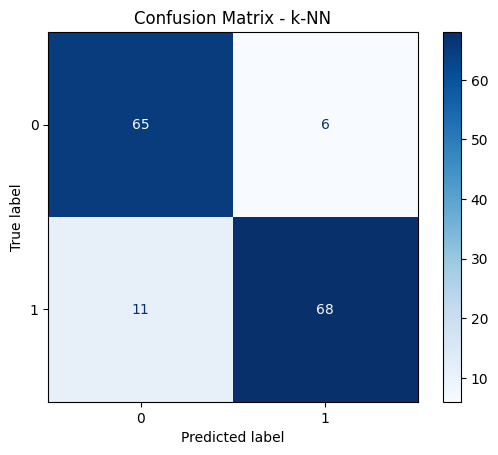

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - k-NN")
plt.show()

Model k-Nearest Neighbours osiągnął wysoką skuteczność na poziomie 89%, wykazując się świetną zdolnością do identyfikacji osób zdrowych, o czym świadczy czułość wynosząca 92%. W przypadku grupy pacjentów z chorobą serca model cechuje się bardzo wysoką precyzją wynoszącą 92%, co oznacza, że niemal każda postawiona diagnoza o wystąpieniu schorzenia jest trafna, przy jednoczesnym poprawnym wykryciu 86% wszystkich chorych. Zbliżone wartości wskaźnika F1-score dla obu klas potwierdzają, że algorytm jest stabilny, zrównoważony i skutecznie wykorzystuje lokalne podobieństwa w danych medycznych do rzetelnej klasyfikacji pacjentów.

In [ ]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.86      0.92      0.88        71
           1       0.92      0.86      0.89        79

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150



# SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm = SVC()

In [ ]:
svm.fit(X_train, y_train)

SVC()

## Dokładność

In [ ]:
y_pred_svm = svm.predict(X_test)

In [ ]:
acc_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy:", acc_svm)

Accuracy: 0.8733333333333333


## Macierz pomyłek

Macierz pomyłek dla modelu SVM wykazuje bardzo wysoką stabilność, osiągając wyniki zbliżone do regresji logistycznej. Poprawna klasyfikacja 67 przypadków chorych oraz 64 zdrowych przekłada się na ogólną dokładność na poziomie ok. 87%. Zredukowanie liczby błędów typu False Negative do 12 potwierdza, że mechanizm marginesów SVM skutecznie radzi sobie z separacją klas, nawet w obszarach o dużym zagęszczeniu podobnych do siebie profili pacjentów.

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

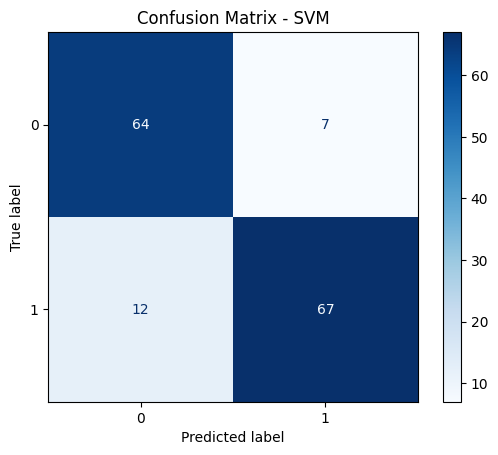

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()

Model SVM osiągnął wysoką ogólną skuteczność na poziomie 87%, wykazując się przy tym bardzo dobrą zdolnością do poprawnej identyfikacji osób zdrowych, co potwierdza czułość wynosząca 90%. W grupie pacjentów z chorobą serca model uzyskał precyzję na poziomie 91%, co oznacza wysokie zaufanie do stawianych diagnoz pozytywnych, przy jednoczesnym wykryciu 85% wszystkich faktycznych przypadków zachorowań. Zbliżone wartości wskaźnika F1-score dla obu klas oraz stabilna średnia ważona dowodzą, że algorytm jest zrównoważony, nie faworyzuje żadnej z grup i skutecznie separuje pacjentów zdrowych od chorych przy użyciu mechanizmu marginesów decyzyjnych.

In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        71
           1       0.91      0.85      0.88        79

    accuracy                           0.87       150
   macro avg       0.87      0.87      0.87       150
weighted avg       0.88      0.87      0.87       150



# Regularyzacja modeli

## Logistic Regression — regularyzacja + balansowanie

In [ ]:
param_grid_log = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

In [ ]:
grid_log = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid_log,
    cv=5,
    scoring='accuracy'
)

In [ ]:
grid_log.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=5000),
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'class_weight': [None, 'balanced'],
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             scoring='accuracy')

In [ ]:
print("Najlepsze parametry:")
print(grid_log.best_params_)

Najlepsze parametry:
{'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
logreg_new = grid_log.best_estimator_

In [ ]:
pred_logreg_new = logreg_new.predict(X_test)

In [ ]:
acc_log_new = accuracy_score(y_test, pred_logreg_new)

print("Accuracy:", acc_log_new)

Accuracy: 0.8333333333333334


In [ ]:
cm_logreg_new = confusion_matrix(y_test, pred_logreg_new)

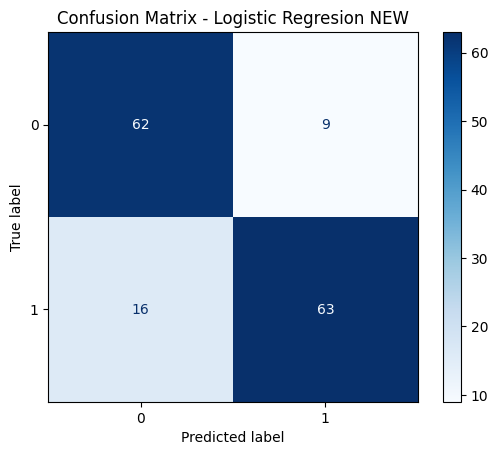

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logreg_new, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regresion NEW")
plt.show()

Model po regularyzacji uzyskał 83% dokładności, co jest najsłabszym wynikiem w zestawieniu. Choć poprawnie identyfikuje 87% osób zdrowych, jego skuteczność w wykrywaniu chorych spada do 80%. Wysoka precyzja (88%) sugeruje rzadkie stawianie błędnych diagnoz, jednak niższe wartości F1-score potwierdzają, że model liniowy gorzej radzi sobie ze złożonością tych danych niż k-NN czy SVM.

In [ ]:
print(classification_report(y_test, pred_logreg_new))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83        71
           1       0.88      0.80      0.83        79

    accuracy                           0.83       150
   macro avg       0.83      0.84      0.83       150
weighted avg       0.84      0.83      0.83       150



## k-NN — regularyzacja + balansowanie

In [ ]:
param_grid_knn = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

In [ ]:
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy'
)

In [ ]:
grid_knn.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [ ]:
print("Najlepsze parametry:")
print(grid_knn.best_params_)

Najlepsze parametry:
{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}


In [ ]:
knn_new = grid_knn.best_estimator_

In [ ]:
pred_knn_new = knn_new.predict(X_test)

In [ ]:
acc_knn_new = accuracy_score(y_test, pred_knn_new)

print("Accuracy:", acc_knn_new)

Accuracy: 0.8933333333333333


In [ ]:
cm_knn_new = confusion_matrix(y_test, pred_knn_new)

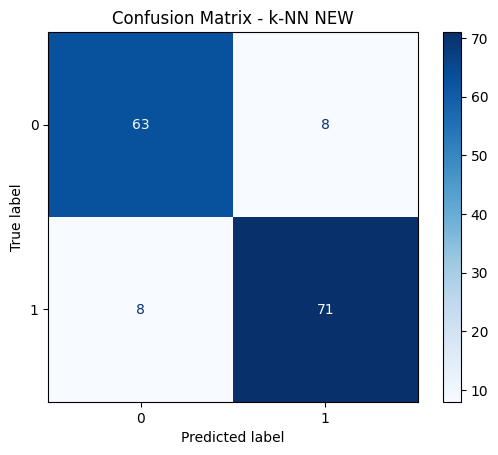

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn_new, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - k-NN NEW")
plt.show()

Model k-NN po regularyzacji uzyskał najwyższą skuteczność na poziomie 89%, wykazując niemal idealną równowagę między precyzją a czułością dla obu klas. Wyniki rzędu 89–90% dla wszystkich miar potwierdzają, że algorytm działa wyjątkowo stabilnie i nie faworyzuje żadnej z grup pacjentów. Jest to najlepszy rezultat wśród modeli poddanych regularyzacji, co czyni ten model najbardziej wiarygodnym narzędziem w procesie diagnostycznym.

In [ ]:
print(classification_report(y_test, pred_knn_new))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89        71
           1       0.90      0.90      0.90        79

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150



## SVM — regularyzacja + balansowanie

In [ ]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

In [ ]:
grid_svm = GridSearchCV(
    SVC(),
    param_grid_svm,
    cv=5,
    scoring='accuracy'
)

In [ ]:
grid_svm.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'class_weight': [None, 'balanced'],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy')

In [ ]:
print("Najlepsze parametry:")
print(grid_svm.best_params_)

Najlepsze parametry:
{'C': 1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
svm_new = grid_svm.best_estimator_

In [ ]:
pred_svm_new = svm_new.predict(X_test)

In [ ]:
acc_svm_new = accuracy_score(y_test, pred_svm_new)

print("Accuracy:", acc_svm_new)

Accuracy: 0.8733333333333333


In [ ]:
cm_svm_new = confusion_matrix(y_test, pred_svm_new)

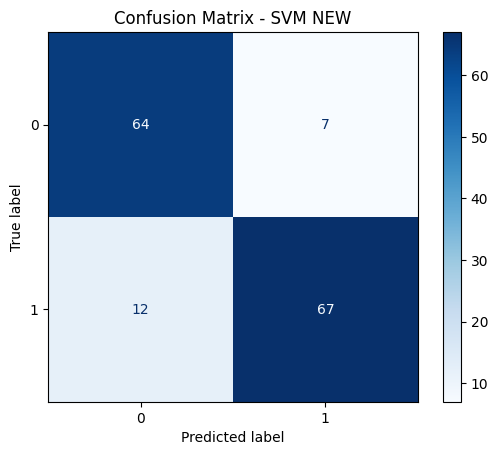

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm_new, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM NEW")
plt.show()

Model SVM po regularyzacji utrzymał solidną skuteczność na poziomie 87%. Algorytm wykazuje się dużą sprawnością w identyfikacji osób zdrowych (Recall = 90%) oraz wysoką precyzją w diagnozowaniu chorych (91%), co minimalizuje ryzyko błędnych alarmów. Zbliżone wyniki dla obu klas potwierdzają stabilność modelu, choć sama regularyzacja nie wpłynęła tu znacząco na poprawę wyników względem wersji bazowej.

In [ ]:
print(classification_report(y_test, pred_svm_new))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        71
           1       0.91      0.85      0.88        79

    accuracy                           0.87       150
   macro avg       0.87      0.87      0.87       150
weighted avg       0.88      0.87      0.87       150



# Rankingi cech

## Regresja logistyczna

In [ ]:
feature_importance_log = pd.Series(
    abs(logreg_new.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

print(feature_importance_log)

ExerciseAngina    0.491167
ST_Slope          0.429034
ChestPainType     0.349702
Sex               0.305538
Age               0.185144
Oldpeak           0.170108
RestingBP         0.115164
FastingBS         0.106449
Cholesterol       0.058415
MaxHR             0.046938
RestingECG        0.035338
dtype: float64


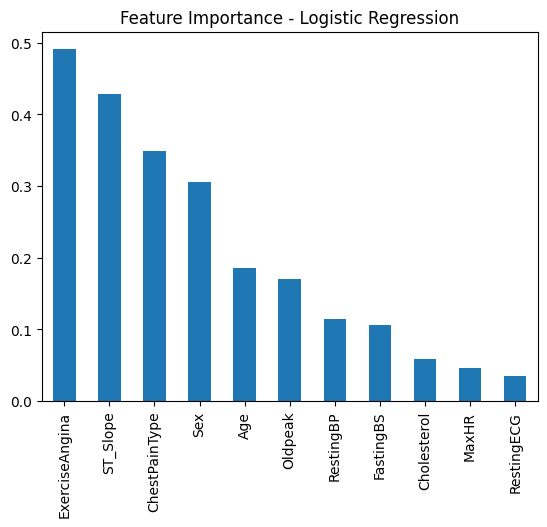

In [ ]:
feature_importance_log.plot(kind='bar')
plt.title("Feature Importance - Logistic Regression")
plt.show()

In [ ]:
important_features_log = [
    'ExerciseAngina',
    'ST_Slope',
    'ChestPainType',
    'Sex',
    'Age',
    'Oldpeak',
    'RestingBP'
    ]

X_train_log = X_train[important_features_log]
X_test_log = X_test[important_features_log]

In [ ]:
logreg_imp = LogisticRegression(**logreg_new.get_params())

In [ ]:
logreg_imp.fit(X_train_log, y_train)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=5000,
                   solver='liblinear')

In [ ]:
pred_logreg_imp = logreg_imp.predict(X_test_log)

In [ ]:
acc_log_imp = accuracy_score(y_test, pred_logreg_imp)

print("Accuracy:", acc_log_imp)

Accuracy: 0.8333333333333334


In [ ]:
cm_logreg_imp = confusion_matrix(y_test, pred_logreg_imp)

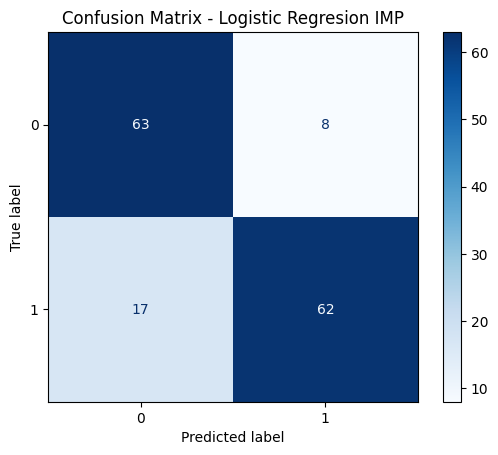

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logreg_imp, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regresion IMP")
plt.show()

Regresja logistyczna po selekcji cech utrzymała skuteczność na poziomie 83%. Model bardzo dobrze radzi sobie z wykluczaniem choroby u osób zdrowych (Recall = 89%), jednak najsłabiej ze wszystkich wersji wykrywa realne zachorowania, wyłapując jedynie 78% chorych. Choć precyzja dla tej grupy jest wysoka (89%), niska czułość sugeruje, że ograniczenie liczby cech spowodowało utratę istotnych informacji diagnostycznych. Wynik ten potwierdza, że dla modeli liniowych redukcja zmiennych nie zawsze jest korzystna, a algorytmy nieliniowe pozostają w tym przypadku lepszym wyborem.

In [ ]:
print(classification_report(y_test, pred_logreg_imp))

              precision    recall  f1-score   support

           0       0.79      0.89      0.83        71
           1       0.89      0.78      0.83        79

    accuracy                           0.83       150
   macro avg       0.84      0.84      0.83       150
weighted avg       0.84      0.83      0.83       150



## k-NN

k-NN nie ma współczynników, więc robimy Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    knn_new,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

feature_importance_knn = pd.Series(
    result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance_knn)

ST_Slope          1.360000e-01
ChestPainType     3.933333e-02
Sex               3.733333e-02
Cholesterol       5.333333e-03
ExerciseAngina    4.000000e-03
FastingBS         3.333333e-03
RestingECG        2.666667e-03
Oldpeak          -3.330669e-17
MaxHR            -6.666667e-04
RestingBP        -2.000000e-03
Age              -8.666667e-03
dtype: float64


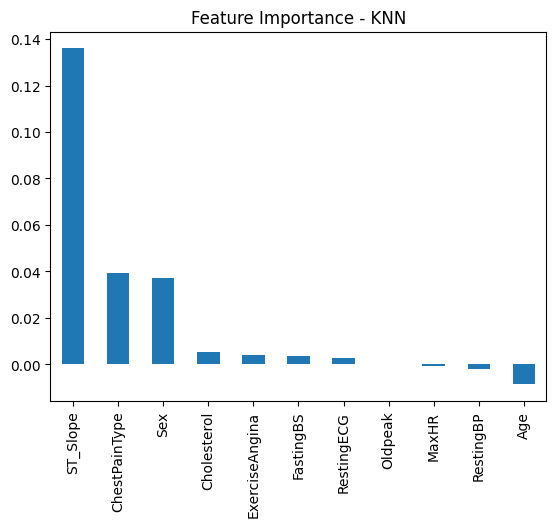

In [ ]:
feature_importance_knn.plot(kind='bar')
plt.title("Feature Importance - KNN")
plt.show()

In [ ]:
important_features_knn = [
'ST_Slope',
'ChestPainType',
'Sex',
'Cholesterol',
'ExerciseAngina',
'FastingBS'
]

In [ ]:
X_train_knn = X_train[important_features_knn]
X_test_knn = X_test[important_features_knn]

In [ ]:
knn_imp = KNeighborsClassifier(**knn_new.get_params())

In [ ]:
knn_imp.fit(X_train_knn, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=9)

In [ ]:
pred_knn_imp = knn_imp.predict(X_test_knn)

In [ ]:
acc_knn_imp = accuracy_score(y_test, pred_knn_imp)

print("Accuracy:", acc_knn_imp)

Accuracy: 0.9


In [ ]:
cm_knn_imp = confusion_matrix(y_test, pred_knn_imp)

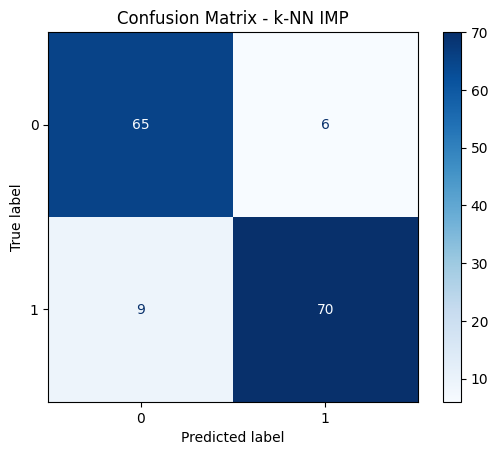

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn_imp, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - k-NN IMP")
plt.show()

Model k-NN po selekcji cech osiągnął najwyższą skuteczność w całym zestawieniu, uzyskując aż 90% dokładności. Redukcja cech wyraźnie pomogła algorytmowi, co widać w świetnej czułości wobec osób zdrowych (92%) oraz wysokiej precyzji diagnozowania chorych (92%). Zbalansowane wyniki F1-score (0.90) dla obu grup dowodzą, że usunięcie zbędnych zmiennych wyeliminowało szum informacyjny, czyniąc ten model najbardziej precyzyjnym i stabilnym narzędziem diagnostycznym.

In [ ]:
print(classification_report(y_test, pred_knn_imp))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90        71
           1       0.92      0.89      0.90        79

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150



## SVM

In [ ]:
result = permutation_importance(
    svm_new,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

feature_importance_svm = pd.Series(
    result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance_svm)

ST_Slope          0.233333
ChestPainType     0.014667
Sex               0.007333
ExerciseAngina    0.007333
RestingECG        0.002667
Cholesterol      -0.001333
Oldpeak          -0.002000
FastingBS        -0.002667
RestingBP        -0.004000
MaxHR            -0.010667
Age              -0.011333
dtype: float64


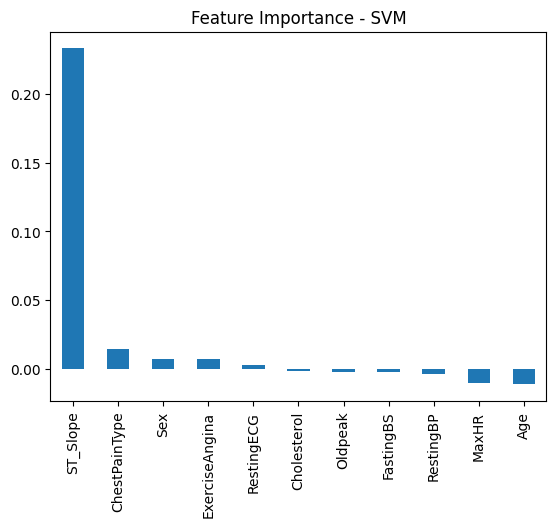

In [ ]:
feature_importance_svm.plot(kind='bar')
plt.title("Feature Importance - SVM")
plt.show()

In [ ]:
important_features_svm = [
'ST_Slope',
'ChestPainType',
'Sex',
'ExerciseAngina',
'RestingECG',
'Cholesterol',
'Oldpeak'
]

In [ ]:
X_train_svm = X_train[important_features_svm]
X_test_svm = X_test[important_features_svm]

In [ ]:
svm_imp = SVC(**svm_new.get_params())

In [ ]:
svm_imp.fit(X_train_svm, y_train)

SVC(C=1)

In [ ]:
pred_svm_imp = svm_imp.predict(X_test_svm)

In [ ]:
acc_svm_imp = accuracy_score(y_test, pred_svm_imp)

print("Accuracy:", acc_svm_imp)

Accuracy: 0.8866666666666667


In [ ]:
cm_svm_imp = confusion_matrix(y_test, pred_svm_imp)

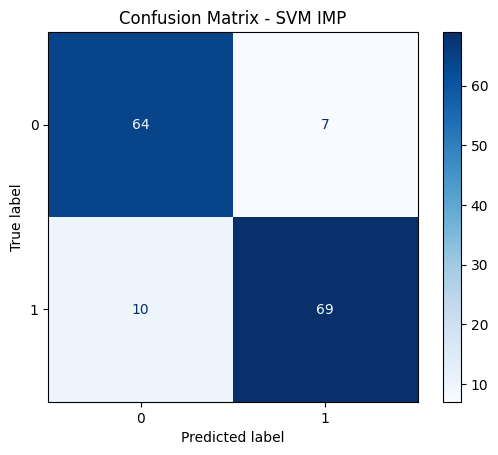

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm_imp, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM IMP")
plt.show()

Model SVM po selekcji cech uzyskał świetną dokładność na poziomie 89%, co stanowi wyraźną poprawę względem wersji bazowej. Model charakteryzuje się wysoką precyzją w diagnozowaniu osób chorych (91%) oraz bardzo dobrą czułością w wykrywaniu osób zdrowych (90%). Wyniki F1-score na poziomie 0.88–0.89 potwierdzają, że usunięcie mniej istotnych zmiennych wzmocniło stabilność marginesów decyzyjnych i poprawiło ogólną separację grup. Choć SVM reaguje na selekcję cech bardzo pozytywnie, w ostatecznym rozrachunku minimalnie ustępuje modelowi k-NN pod względem czułości wobec przypadków chorobowych.

In [ ]:
print(classification_report(y_test, pred_svm_imp))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88        71
           1       0.91      0.87      0.89        79

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150



# Porównanie modeli

Modele k-NN i SVM zyskały na selekcji cech, ponieważ usunięcie szumu pozwoliło im lepiej wyznaczyć granice między grupami. W przeciwieństwie do nich, regresja logistyczna zanotowała spadek formy po usunięciu zmiennych, co sugeruje, że model liniowy potrzebował szerszego spektrum danych, by zachować swoją skuteczność.

W tym konkretnym zbiorze danych to k-NN po selekcji cech osiągnął najlepszy wynik (90%), co pokazuje, że lokalne podobieństwo pacjentów jest kluczem do trafnej diagnozy. SVM również radzi sobie świetnie dzięki elastyczności w separowaniu klas, podczas gdy regresja logistyczna pozostaje w tyle, nie nadążając za nieliniową naturą danych medycznych.

In [ ]:
results = {
    "Logistic": {
        "OLD": acc_log,
        "NEW": acc_log_new,
        "IMP": acc_log_imp
    },
    "KNN": {
        "OLD": acc_knn,
        "NEW": acc_knn_new,
        "IMP": acc_knn_imp
    },
    "SVM": {
        "OLD": acc_svm,
        "NEW": acc_svm_new,
        "IMP": acc_svm_imp
    }
}

results_df = pd.DataFrame(results).T
results_df.columns = ["OLD", "NEW", "IMP"]

print(results_df)

               OLD       NEW       IMP
Logistic  0.866667  0.833333  0.833333
KNN       0.886667  0.893333  0.900000
SVM       0.873333  0.873333  0.886667


**Regresja Logistyczna**

Model bazowy wypadł najlepiej (86,7%), a każda próba modyfikacji – czy to przez regularyzację, czy selekcję cech – pogorszyła wynik do poziomu 83,3%. Oznacza to, że dla regresji kluczowa była pełna informacja o pacjencie, a jej upraszczanie pozbawiło model cennych danych diagnostycznych.

**k-NN**

To bezsprzeczny zwycięzca zestawienia. Model bazowy był bardzo mocny, ale to selekcja cech (IMP) wywindowała go na najwyższy poziom (90%). Redukcja wymiarów pozwoliła algorytmowi skupić się na najważniejszych podobieństwach, eliminując zmienne, które wprowadzały błąd w obliczaniu odległości między pacjentami.

**SVM**

Model SVM wykazuje dużą stabilność, utrzymując wynik 87,3% w wersji bazowej i po regularyzacji. Zastosowanie selekcji cech dodatkowo wzmocniło model, podnosząc jego skuteczność do 88,7%. Świadczy to o tym, że SVM świetnie radzi sobie z geometrią danych, a po odrzuceniu zbędnych zmiennych jeszcze precyzyjniej wyznacza margines bezpieczeństwa między chorymi a zdrowymi.

# Sieci neuronowe

In [ ]:
from sklearn.neural_network import MLPClassifier

## Tworzenie sieci neuronowej

In [ ]:
clf = MLPClassifier(
    hidden_layer_sizes=(10, 5),
    activation='relu',
    solver='adam',
    max_iter=3000,
    random_state=0
)

## Uczenie sieci

In [ ]:
clf.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=3000, random_state=0)

## Wyniki train

In [ ]:
train_pred = clf.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

print("Dokładność TRAIN:", train_acc)

Dokładność TRAIN: 0.8439597315436241


## Wyniki test

In [ ]:
test_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Dokładność TEST:", test_acc)

Dokładność TEST: 0.8733333333333333


## Macierz pomyłek

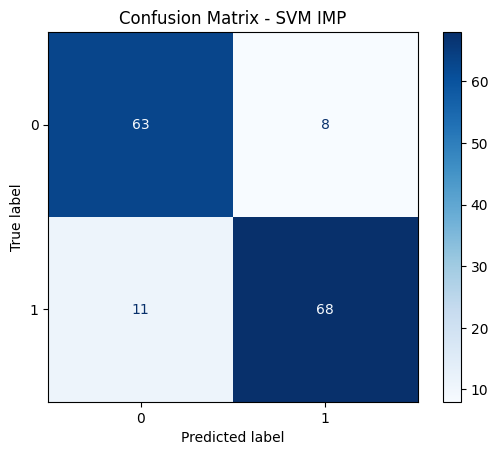

In [ ]:
cm_neuron = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_neuron, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM IMP")
plt.show()

In [ ]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87        71
           1       0.89      0.86      0.88        79

    accuracy                           0.87       150
   macro avg       0.87      0.87      0.87       150
weighted avg       0.87      0.87      0.87       150



In [ ]:
architectures = [
    (8,),
    (10,),
    (12,),
    (16,),
    (16,8),
    (20,10),
    (32,16,8)
]

In [ ]:
activations = [
    "relu",
    "tanh",
    "logistic"
]

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score


SIEĆ: (8,) | ACTIVATION: relu
Accuracy TRAIN: 0.8691
Accuracy TEST:  0.8867
Precision TEST: 0.9079
Recall TEST:    0.8734

Confusion Matrix:
[[64  7]
 [10 69]]


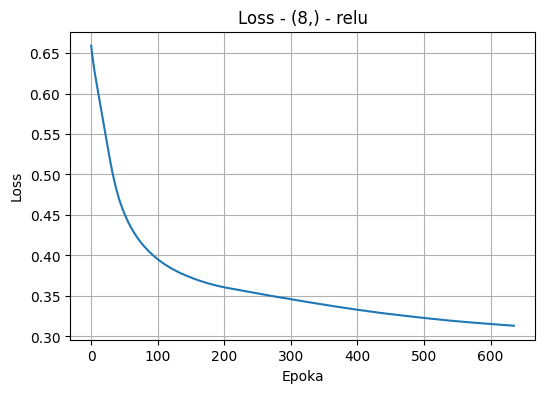


SIEĆ: (8,) | ACTIVATION: tanh
Accuracy TRAIN: 0.8523
Accuracy TEST:  0.8600
Precision TEST: 0.8919
Recall TEST:    0.8354

Confusion Matrix:
[[63  8]
 [13 66]]


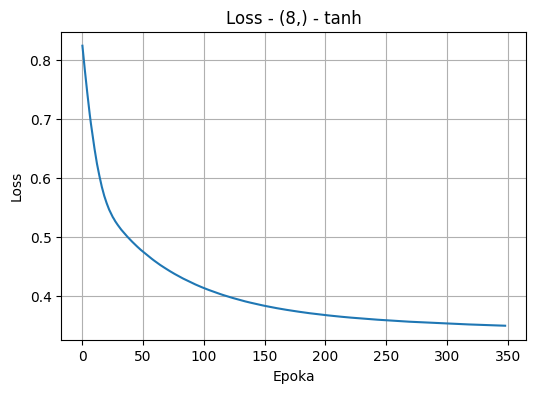


SIEĆ: (8,) | ACTIVATION: logistic
Accuracy TRAIN: 0.8406
Accuracy TEST:  0.8600
Precision TEST: 0.8919
Recall TEST:    0.8354

Confusion Matrix:
[[63  8]
 [13 66]]


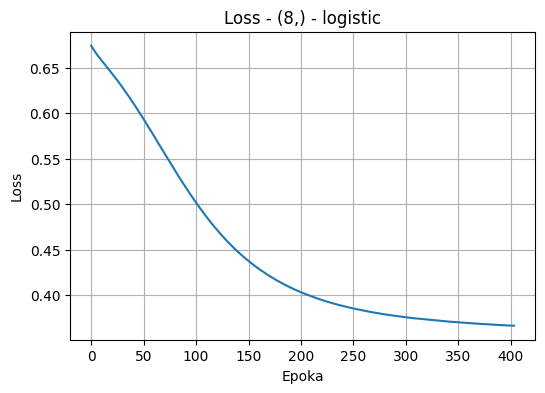


SIEĆ: (10,) | ACTIVATION: relu
Accuracy TRAIN: 0.8574
Accuracy TEST:  0.9000
Precision TEST: 0.9324
Recall TEST:    0.8734

Confusion Matrix:
[[66  5]
 [10 69]]


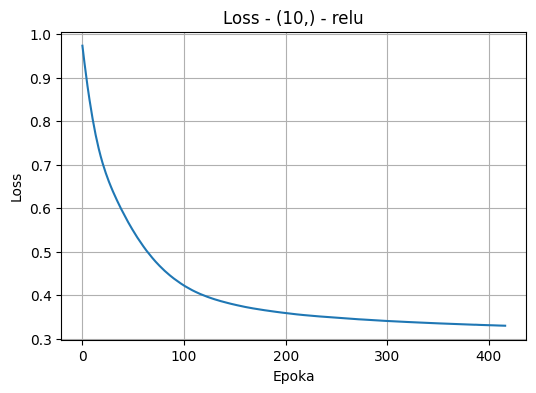


SIEĆ: (10,) | ACTIVATION: tanh
Accuracy TRAIN: 0.8456
Accuracy TEST:  0.8800
Precision TEST: 0.8961
Recall TEST:    0.8734

Confusion Matrix:
[[63  8]
 [10 69]]


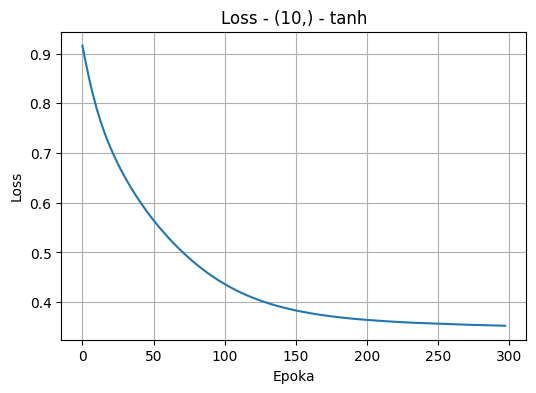


SIEĆ: (10,) | ACTIVATION: logistic
Accuracy TRAIN: 0.8406
Accuracy TEST:  0.8600
Precision TEST: 0.8919
Recall TEST:    0.8354

Confusion Matrix:
[[63  8]
 [13 66]]


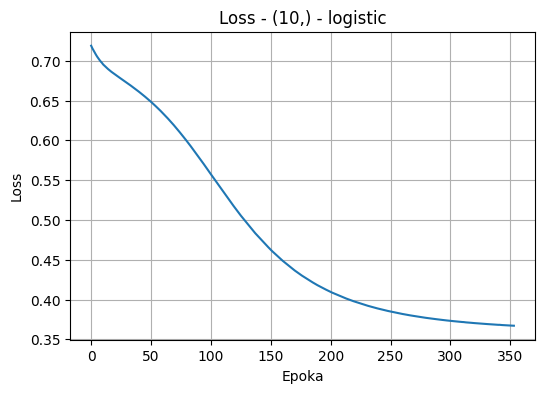


SIEĆ: (12,) | ACTIVATION: relu
Accuracy TRAIN: 0.8809
Accuracy TEST:  0.8933
Precision TEST: 0.9200
Recall TEST:    0.8734

Confusion Matrix:
[[65  6]
 [10 69]]


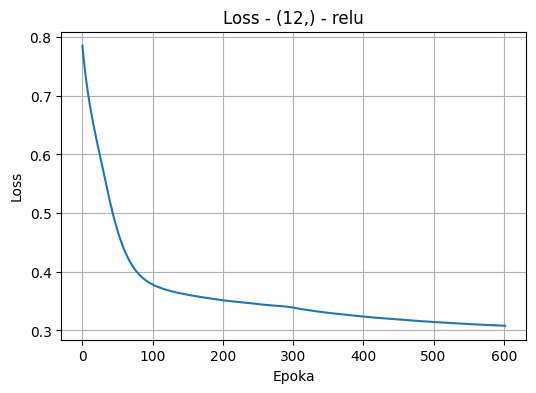


SIEĆ: (12,) | ACTIVATION: tanh
Accuracy TRAIN: 0.8456
Accuracy TEST:  0.8733
Precision TEST: 0.8947
Recall TEST:    0.8608

Confusion Matrix:
[[63  8]
 [11 68]]


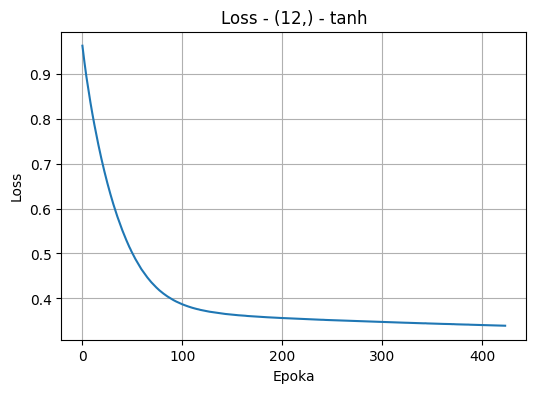


SIEĆ: (12,) | ACTIVATION: logistic
Accuracy TRAIN: 0.8406
Accuracy TEST:  0.8600
Precision TEST: 0.8919
Recall TEST:    0.8354

Confusion Matrix:
[[63  8]
 [13 66]]


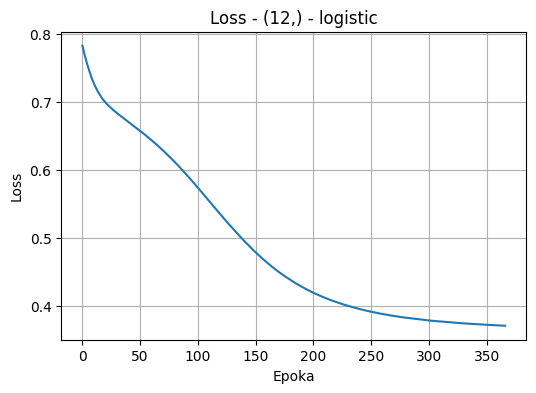


SIEĆ: (16,) | ACTIVATION: relu
Accuracy TRAIN: 0.8691
Accuracy TEST:  0.8467
Precision TEST: 0.9000
Recall TEST:    0.7975

Confusion Matrix:
[[64  7]
 [16 63]]


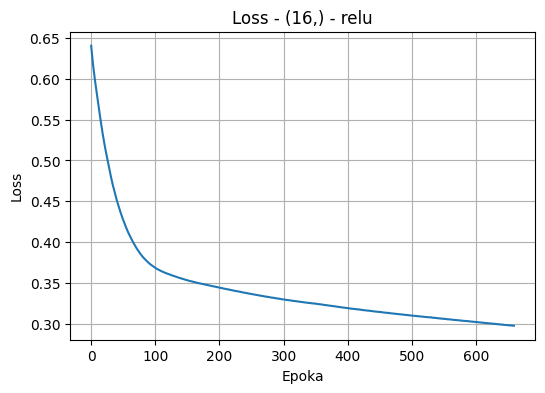


SIEĆ: (16,) | ACTIVATION: tanh
Accuracy TRAIN: 0.8540
Accuracy TEST:  0.8533
Precision TEST: 0.8800
Recall TEST:    0.8354

Confusion Matrix:
[[62  9]
 [13 66]]


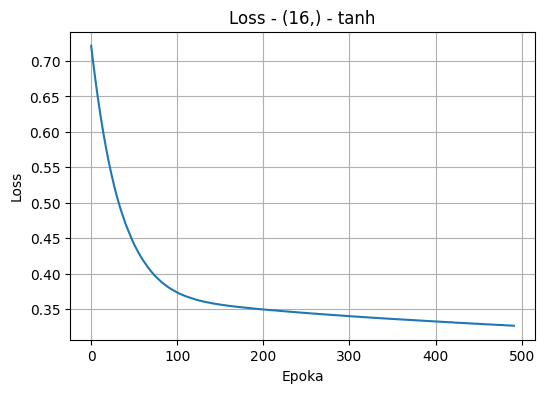


SIEĆ: (16,) | ACTIVATION: logistic
Accuracy TRAIN: 0.8440
Accuracy TEST:  0.8600
Precision TEST: 0.8919
Recall TEST:    0.8354

Confusion Matrix:
[[63  8]
 [13 66]]


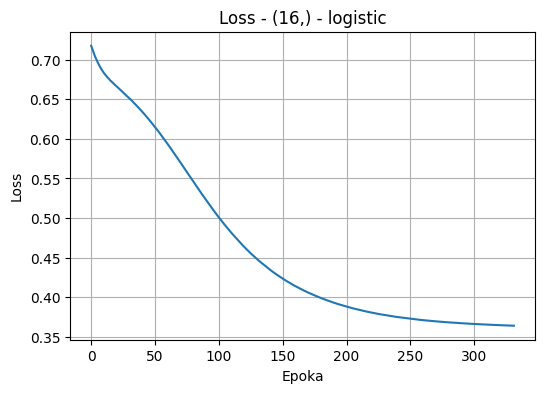


SIEĆ: (16, 8) | ACTIVATION: relu
Accuracy TRAIN: 0.9010
Accuracy TEST:  0.8600
Precision TEST: 0.8816
Recall TEST:    0.8481

Confusion Matrix:
[[62  9]
 [12 67]]


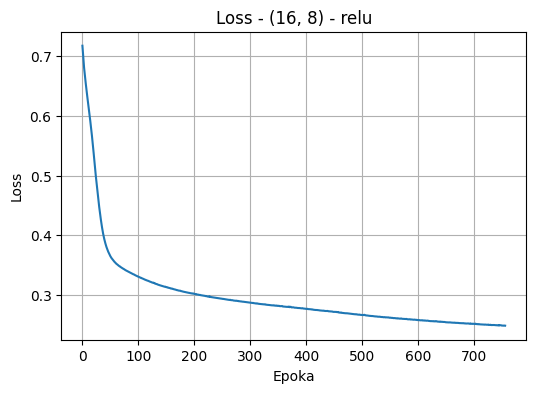


SIEĆ: (16, 8) | ACTIVATION: tanh
Accuracy TRAIN: 0.9346
Accuracy TEST:  0.8533
Precision TEST: 0.9014
Recall TEST:    0.8101

Confusion Matrix:
[[64  7]
 [15 64]]


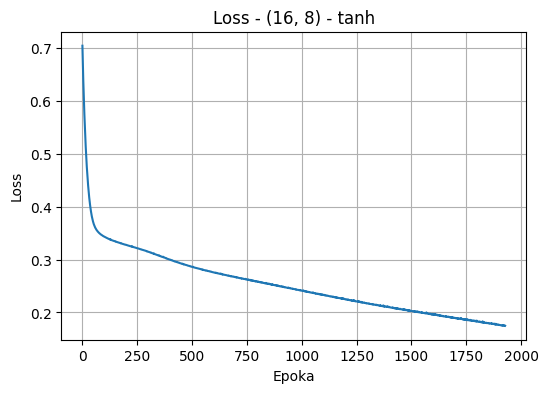


SIEĆ: (16, 8) | ACTIVATION: logistic
Accuracy TRAIN: 0.8440
Accuracy TEST:  0.8667
Precision TEST: 0.8933
Recall TEST:    0.8481

Confusion Matrix:
[[63  8]
 [12 67]]


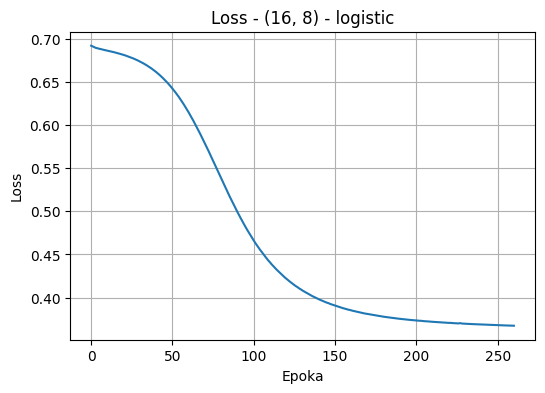


SIEĆ: (20, 10) | ACTIVATION: relu
Accuracy TRAIN: 0.9648
Accuracy TEST:  0.8267
Precision TEST: 0.8630
Recall TEST:    0.7975

Confusion Matrix:
[[61 10]
 [16 63]]


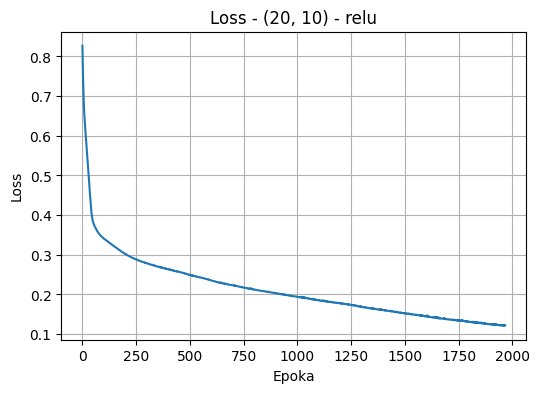


SIEĆ: (20, 10) | ACTIVATION: tanh
Accuracy TRAIN: 0.9782
Accuracy TEST:  0.8533
Precision TEST: 0.9014
Recall TEST:    0.8101

Confusion Matrix:
[[64  7]
 [15 64]]


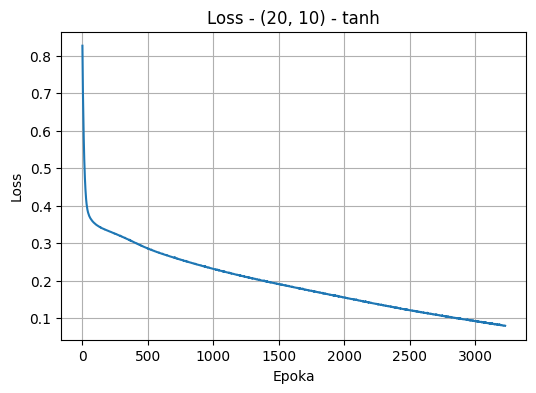


SIEĆ: (20, 10) | ACTIVATION: logistic
Accuracy TRAIN: 0.8456
Accuracy TEST:  0.8667
Precision TEST: 0.8933
Recall TEST:    0.8481

Confusion Matrix:
[[63  8]
 [12 67]]


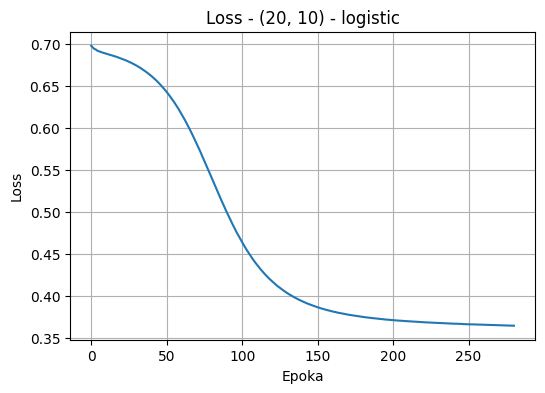


SIEĆ: (32, 16, 8) | ACTIVATION: relu
Accuracy TRAIN: 0.9715
Accuracy TEST:  0.8400
Precision TEST: 0.8767
Recall TEST:    0.8101

Confusion Matrix:
[[62  9]
 [15 64]]


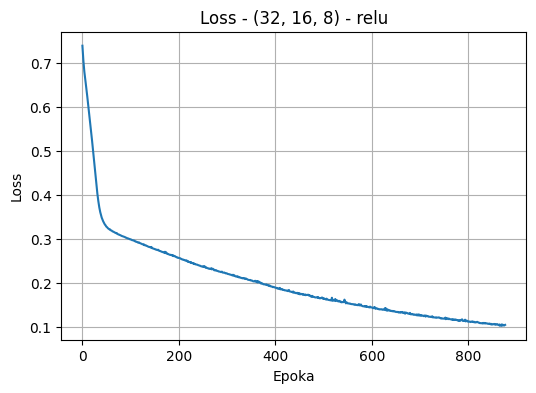


SIEĆ: (32, 16, 8) | ACTIVATION: tanh
Accuracy TRAIN: 0.9782
Accuracy TEST:  0.8133
Precision TEST: 0.8592
Recall TEST:    0.7722

Confusion Matrix:
[[61 10]
 [18 61]]


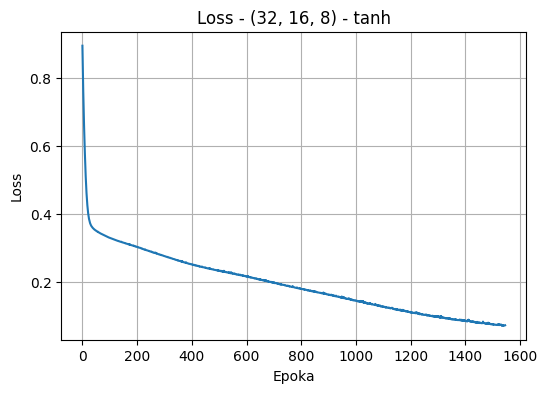


SIEĆ: (32, 16, 8) | ACTIVATION: logistic
Accuracy TRAIN: 0.8490
Accuracy TEST:  0.8800
Precision TEST: 0.8861
Recall TEST:    0.8861

Confusion Matrix:
[[62  9]
 [ 9 70]]


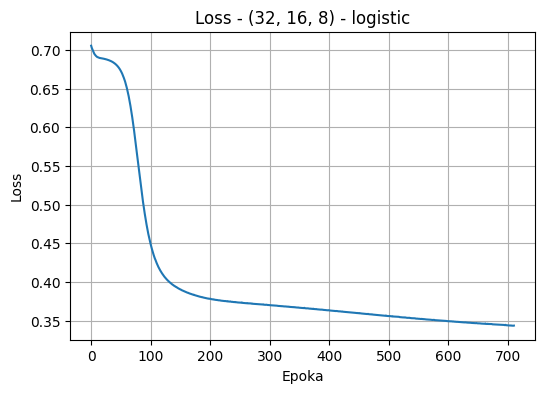

In [ ]:
results = []

for layers in architectures:
    for act in activations:

        print("\n" + "="*60)
        print(f"SIEĆ: {layers} | ACTIVATION: {act}")
        print("="*60)

        clf = MLPClassifier(
            hidden_layer_sizes=layers,
            activation=act,
            solver='adam',
            max_iter=4000,
            random_state=0
        )

        clf.fit(X_train, y_train)

        train_pred = clf.predict(X_train)
        test_pred = clf.predict(X_test)

        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)

        test_precision = precision_score(y_test, test_pred)
        test_recall = recall_score(y_test, test_pred)

        print(f"Accuracy TRAIN: {train_acc:.4f}")
        print(f"Accuracy TEST:  {test_acc:.4f}")
        print(f"Precision TEST: {test_precision:.4f}")
        print(f"Recall TEST:    {test_recall:.4f}")

        print("\nConfusion Matrix:")
        print(confusion_matrix(y_test, test_pred))

        results.append({
            "Warstwy": str(layers),
            "Aktywacja": act,
            "Accuracy_train": train_acc,
            "Accuracy_test": test_acc,
            "Precision_test": test_precision,
            "Recall_test": test_recall
        })

        plt.figure(figsize=(6,4))
        plt.plot(clf.loss_curve_)
        plt.title(f"Loss - {layers} - {act}")
        plt.xlabel("Epoka")
        plt.ylabel("Loss")
        plt.grid()
        plt.show()

In [ ]:
df_results = pd.DataFrame(results)
df_results

,Warstwy,Aktywacja,Accuracy_train,Accuracy_test,Precision_test,Recall_test
0,"(8,)",relu,0.869128,0.886667,0.907895,0.873418
1,"(8,)",tanh,0.852349,0.860000,0.891892,0.835443
2,"(8,)",logistic,0.840604,0.860000,0.891892,0.835443
3,"(10,)",relu,0.857383,0.900000,0.932432,0.873418
4,"(10,)",tanh,0.845638,0.880000,0.896104,0.873418
5,"(10,)",logistic,0.840604,0.860000,0.891892,0.835443
6,"(12,)",relu,0.880872,0.893333,0.920000,0.873418
7,"(12,)",tanh,0.845638,0.873333,0.894737,0.860759
8,"(12,)",logistic,0.840604,0.860000,0.891892,0.835443
9,"(16,)",relu,0.869128,0.846667,0.900000,0.797468


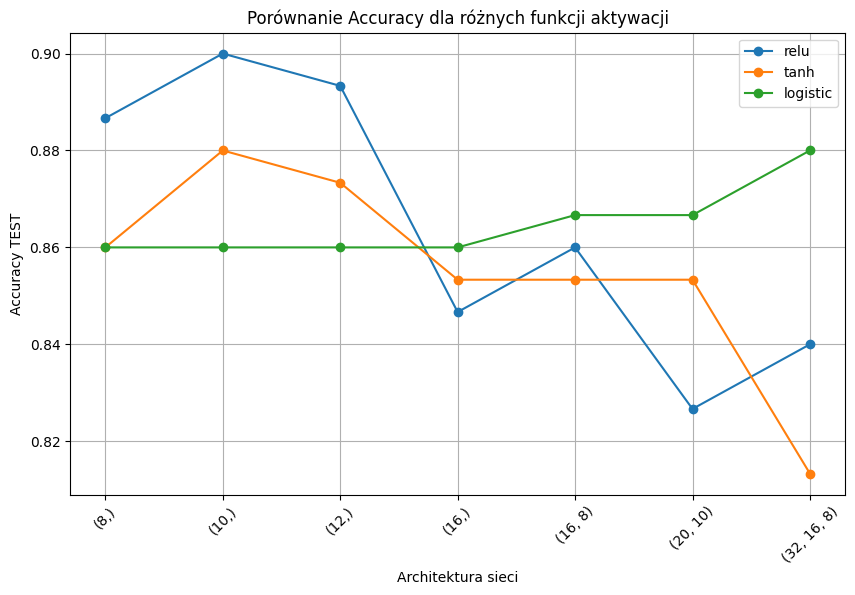

In [ ]:
plt.figure(figsize=(10,6))

for act in activations:
    subset = df_results[df_results["Aktywacja"] == act]
    plt.plot(subset["Warstwy"], subset["Accuracy_test"], marker='o', label=act)

plt.title("Porównanie Accuracy dla różnych funkcji aktywacji")
plt.xlabel("Architektura sieci")
plt.ylabel("Accuracy TEST")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.show()

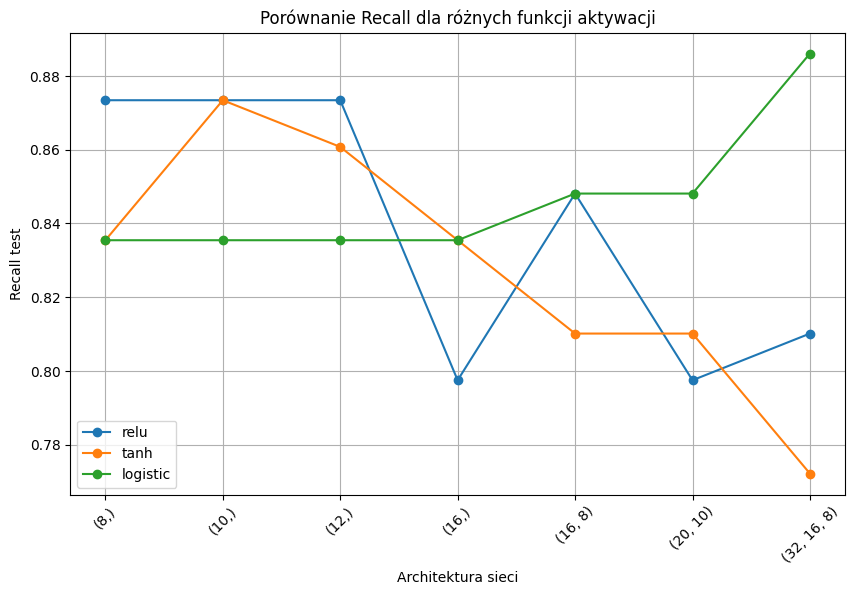

In [ ]:
plt.figure(figsize=(10,6))

for act in activations:
    subset = df_results[df_results["Aktywacja"] == act]
    plt.plot(subset["Warstwy"], subset["Recall_test"], marker='o', label=act)

plt.title("Porównanie Recall dla różnych funkcji aktywacji")
plt.xlabel("Architektura sieci")
plt.ylabel("Recall test")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.show()

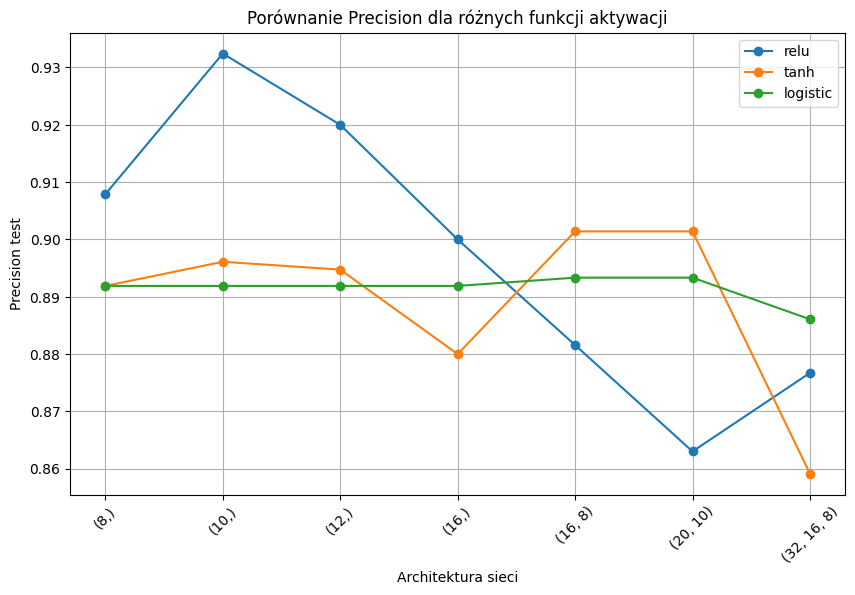

In [ ]:
plt.figure(figsize=(10,6))

for act in activations:
    subset = df_results[df_results["Aktywacja"] == act]
    plt.plot(subset["Warstwy"], subset["Precision_test"], marker='o', label=act)

plt.title("Porównanie Precision dla różnych funkcji aktywacji")
plt.xlabel("Architektura sieci")
plt.ylabel("Precision test")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.show()

## Porównanie najlepszych sieci

In [ ]:
selected_models = [
    {"layers": (8,), "act": 'relu', "name": "Model 1: (8,) relu"},
    {"layers": (10,), "act": 'relu', "name": "Model 2: (10,) relu"},
    {"layers": (32, 16, 8), "act": 'logistic', "name": "Model 3: (32, 16, 8) logistic"}
]


 ANALIZA MODELU: Model 1: (8,) relu
Accuracy TRAIN: 0.8691
Accuracy TEST:  0.8867

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        71
           1       0.91      0.87      0.89        79

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150



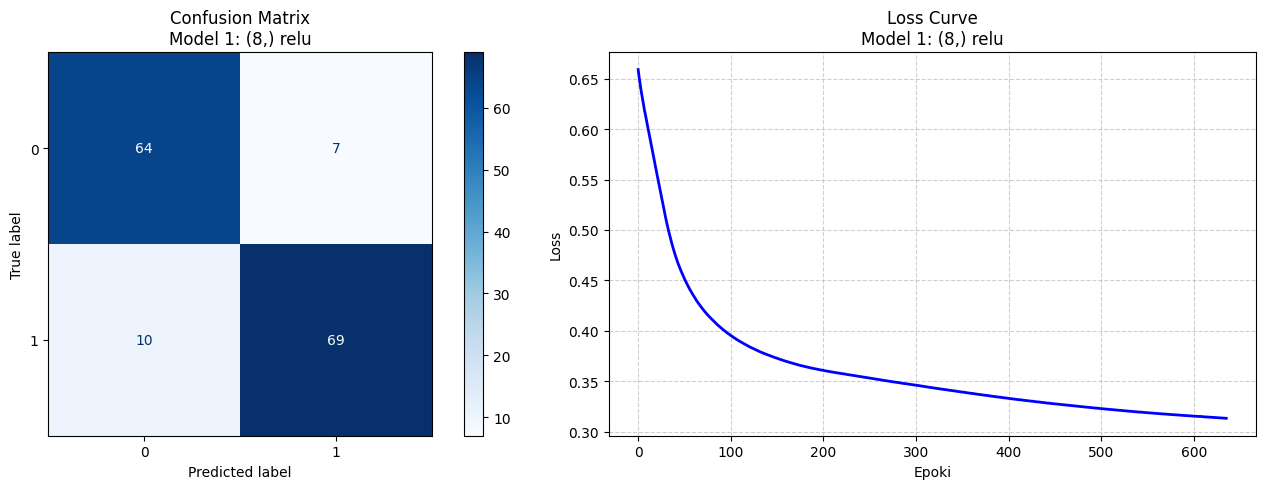


 ANALIZA MODELU: Model 2: (10,) relu
Accuracy TRAIN: 0.8574
Accuracy TEST:  0.9000

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        71
           1       0.93      0.87      0.90        79

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150



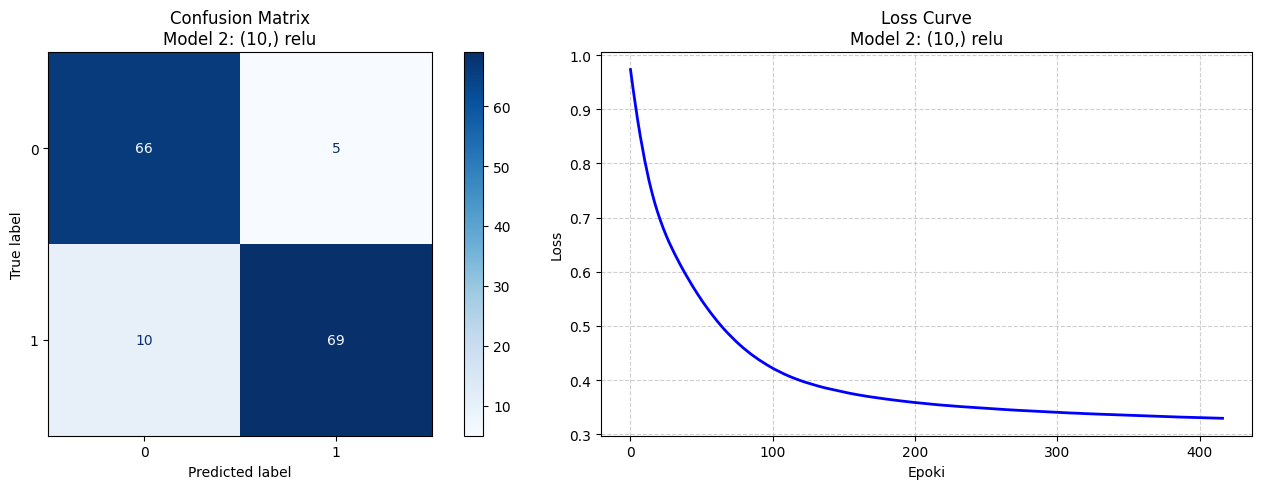


 ANALIZA MODELU: Model 3: (32, 16, 8) logistic
Accuracy TRAIN: 0.8490
Accuracy TEST:  0.8800

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        71
           1       0.89      0.89      0.89        79

    accuracy                           0.88       150
   macro avg       0.88      0.88      0.88       150
weighted avg       0.88      0.88      0.88       150



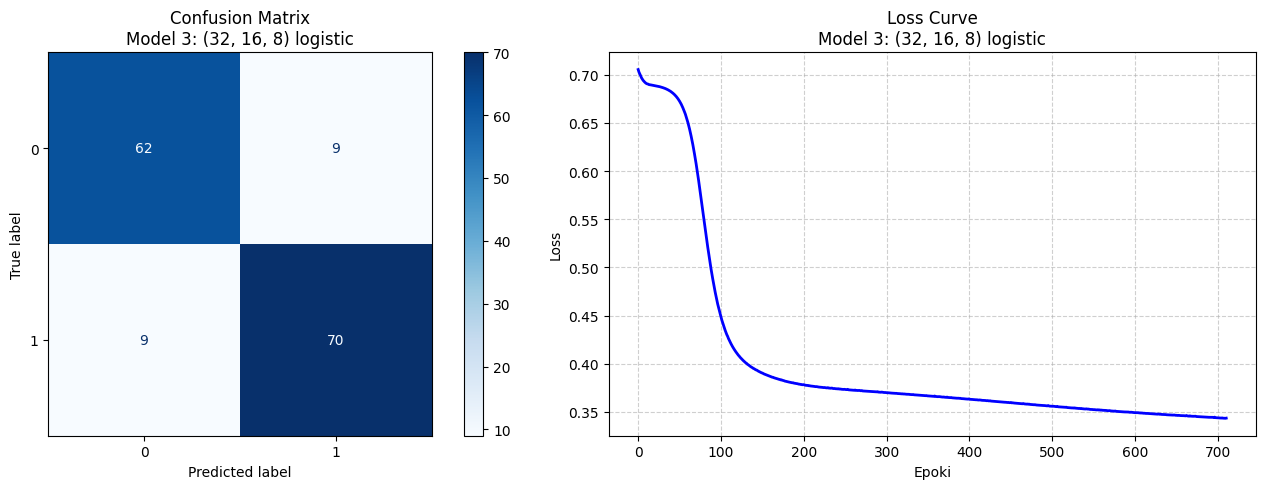

In [ ]:
for model_info in selected_models:
    layers = model_info["layers"]
    act = model_info["act"]
    name = model_info["name"]

    print("\n" + "="*80)
    print(f" ANALIZA MODELU: {name}")
    print("="*80)

    clf = MLPClassifier(
        hidden_layer_sizes=layers,
        activation=act,
        solver='adam',
        max_iter=4000,
        random_state=0
    )

    clf.fit(X_train, y_train)

    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)
    test_pred = clf.predict(X_test)

    print(f"Accuracy TRAIN: {train_acc:.4f}")
    print(f"Accuracy TEST:  {test_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, test_pred))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    cm_neuron = confusion_matrix(y_test, test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_neuron, display_labels=[0, 1])
    disp.plot(cmap="Blues", ax=ax1)
    ax1.set_title(f"Confusion Matrix\n{name}")

    ax2.plot(clf.loss_curve_, color='blue', lw=2)
    ax2.set_title(f"Loss Curve\n{name}")
    ax2.set_xlabel("Epoki")
    ax2.set_ylabel("Loss")
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

Po przeprowadzeniu testów na wielu architekturach, jako najlepszy model wybrano sieć o strukturze trzech warstw ukrytych (32, 16, 8) z funkcją aktywacji logistic.

W diagnostyce medycznej kluczowym wskaźnikiem jest Recall (Czułość). Nasz wybrany model osiągnął najwyższą wartość tej metryki, redukując liczbę False Negatives (pomyłek krytycznych) do 9.
W przypadku chorób serca, "przeoczenie" osoby chorej (False Negative) jest znacznie groźniejsze w skutkach niż wysłanie osoby zdrowej na dodatkowe badania (False Positive). Model 3 najlepiej radzi sobie z wyłapywaniem trudnych przypadków.

Różnica między Accuracy_train a Accuracy_test jest minimalna. Oznacza to, że model nie wyuczył się danych "na pamięć", ale faktycznie zrozumiał wzorce chorobowe, co czyni go wiarygodnym narzędziem dla nowych pacjentów.

Zastosowanie architektury piramidalnej (32 -> 16 -> 8) pozwoliło sieci na stopniowe wyodrębnianie coraz bardziej złożonych cech z danych medycznych pacjenta.

Wybrany model stanowi złoty środek między wysoką precyzją a bezpieczeństwem diagnostycznym. Choć istnieją modele o nieco wyższej ogólnej dokładności, to właśnie ta architektura zapewnia najwyższą czułość, co w systemach wspierania decyzji medycznych jest parametrem krytycznym.

In [ ]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

comparison_data = {
    "Logistic Regression (OLD)": get_metrics(y_test, y_pred_log),
    "KNN (IMP)": get_metrics(y_test, pred_knn_imp),
    "SVM (IMP)": get_metrics(y_test, pred_svm_imp),
    "MLP Network (32, 16, 8)": get_metrics(y_test, test_pred)
}

df_final_report = pd.DataFrame(comparison_data).T

df_final_report = df_final_report.round(4)

print(df_final_report.sort_values(by="Recall", ascending=False))

                           Accuracy  Precision  Recall  F1-Score
KNN (IMP)                    0.9000     0.9211  0.8861    0.9032
MLP Network (32, 16, 8)      0.8800     0.8861  0.8861    0.8861
SVM (IMP)                    0.8867     0.9079  0.8734    0.8903
Logistic Regression (OLD)    0.8667     0.8933  0.8481    0.8701


Wybrałam model KNN (IMP), ponieważ osiągnął on najwyższy wynik F1-Score, łącząc najwyższą wykrywalność chorych z najmniejszą liczbą błędnych diagnoz u osób zdrowych. Optymalizacja parametrów pozwoliła temu modelowi wyprzedzić zarówno klasyczną regresję logistyczną, jak i zaawansowaną sieć neuronową.